# Signal Attribution: What Drives the IC in S&P 500 Options?

This diagnostic studies the legacy 10-session delta-hedged straddle label,
which remains available for structural analysis but is excluded from model
selection and backtesting. It decomposes validation IC into four sources:

1. **Feature ablation**: How much signal comes from IV-related features
   vs realized-volatility and microstructure features?
2. **Lag decay**: Does IV signal persist over days/weeks (genuine VRP)
   or decay immediately (same-period overlap)?
3. **Return decomposition**: Does the model predict the option-specific
   VRP component or just equity direction?
4. **Effective dimensionality**: How many independent signals does the
   current feature panel contain?

**Learning Objectives**:
- Decompose IC into IV-dependent and IV-independent feature contributions
- Measure IV signal persistence via lag decay
- Separate the VRP component from equity direction via return decomposition
- Assess effective dimensionality of the feature space

**Book Reference**: Chapter 11, Section 11.4 (Case Study Analysis)

**Prerequisites**: `financial_features.py`, `model_based_features.py`, `linear.py`

In [1]:
"""Signal attribution for the diagnostic S&P 500 options label."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from ml4t.diagnostic.metrics import compute_ic_uncertainty, cross_sectional_ic_series
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

from utils.modeling import load_modeling_dataset, prepare_cv_folds
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "sp500_options"
PRIMARY_LABEL = "fwd_ret_dh_10d"
MAX_SYMBOLS = 0
MAX_FOLDS = 0
SEED = 42

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
set_global_seeds(SEED)

## 1. Load Data

Load the primary modeling dataset (features + temporal + delta-hedged labels)
and the unhedged label for return decomposition.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
join_cols = mds.join_cols
entity_cols = mds.entity_cols
splits = mds.splits
if MAX_FOLDS:
    splits = splits[:MAX_FOLDS]

print(f"Dataset: {len(dataset):,} rows × {len(feature_names)} features")
print(f"Label: {label_col} | Splits: {len(splits)}")
for s in splits:
    print(
        f"  Fold {s['fold']}: train {str(s['train_start'])[:10]}→{str(s['train_end'])[:10]}  "
        f"val {str(s['val_start'])[:10]}→{str(s['val_end'])[:10]}"
    )

Dataset: 324,920 rows × 51 features
Label: fwd_ret_dh_10d | Splits: 2
  Fold 0: train 2018-01-05→2019-12-18  val 2020-01-06→2020-12-31
  Fold 1: train 2017-02-02→2018-12-19  val 2019-01-07→2020-01-03


Restrict all explanatory evaluation to the union of the two validation
windows. The 2021 holdout is never loaded into a diagnostic calculation.

In [5]:
validation_panels = [
    dataset.filter(
        pl.col(date_col)
        .cast(pl.Date)
        .is_between(
            pl.lit(split["val_start"]).cast(pl.Date),
            pl.lit(split["val_end"]).cast(pl.Date),
            closed="both",
        )
    )
    for split in splits
]
validation_dataset = pl.concat(validation_panels).unique(subset=join_cols).sort(join_cols)
assert validation_dataset[date_col].max() < dataset[date_col].max(), (
    "Diagnostic validation panel unexpectedly reaches the dataset endpoint"
)
print(
    f"Validation-only diagnostic panel: {len(validation_dataset):,} rows, "
    f"{validation_dataset[date_col].n_unique():,} dates"
)

Validation-only diagnostic panel: 132,583 rows, 502 dates


In [6]:
# Load the matching unhedged diagnostic label for return decomposition.
unhedged_label = pl.read_parquet(CASE_DIR / "labels" / "fwd_ret_10d.parquet")
print(f"Unhedged label: {len(unhedged_label):,} rows")

Unhedged label: 333,102 rows


## 2. Feature Taxonomy

Classify all 51 features into two groups:
- **Group A (IV-dependent)**: features whose value is derived from or mechanically
  depends on implied volatility - IV levels, z-scores, VRP, Greeks (all functions
  of IV via Black-Scholes), straddle price/returns (proportional to IV)
- **Group B (IV-independent)**: underlying returns, realized vol, volume,
  bid-ask spread, DTE, model-based vol estimates, quality flags

In [7]:
GROUP_A_LEVELS = [
    # IV levels and z-scores
    "iv_atm",
    "call_iv",
    "put_iv",
    "iv_skew_atm",
    "iv_atm_z_63",
    "iv_atm_z_252",
    # IV momentum
    "iv_mom_5d",
    "iv_mom_10d",
    "iv_mom_21d",
    # IV cross-sectional rank
    "iv_atm_pctl",
    # VRP features (IV - RV)
    "vrp_5d",
    "vrp_10d",
    "vrp_21d",
    "vrp_42d",
    "vrp_63d",
    "iv_rv_ratio",
    "vrp_zscore_252",
    "vrp_mom_5d",
    "vrp_mom_10d",
    # VRP cross-sectional ranks
    "vrp_21d_pctl",
    "iv_rv_ratio_pctl",
    # Temporal VRP (IV minus model-based vol)
    "garch_vrp",
    "sv_vrp",
]

Option sensitivities and straddle-price transformations complete Group A.

In [8]:
GROUP_A_OPTION = [
    "instr_delta",
    "abs_net_delta",
    "instr_gamma",
    "instr_theta",
    "instr_vega",
    "theta_vega_ratio",
    # Straddle price/returns (proportional to IV)
    "instr_pct_of_S",
    "instr_ret_1d",
    "instr_ret_5d",
    "instr_cost_mom_5d",
]
GROUP_A = GROUP_A_LEVELS + GROUP_A_OPTION

Group B contains measurements that do not mechanically depend on implied
volatility.

In [9]:
GROUP_B = [
    # Underlying returns
    "ret_1d",
    "ret_5d",
    "ret_10d",
    "ret_21d",
    # Realized volatility
    "rv_5d",
    "rv_10d",
    "rv_21d",
    "rv_42d",
    "rv_63d",
    # Volume
    "volume_zscore",
    # Microstructure
    "instr_rel_spread",
    "spread_pctl",
    # Time to expiry
    "instr_dte",
    "dte_normalized",
    # Model-based vol estimates (not IV)
    "garch_cond_vol",
    "sv_vol",
    # Quality flags
    "qc_both_converged",
    "qc_any_estimated_iv",
]

Require the taxonomy to cover the current feature vector exactly while
allowing the documented optional stochastic-volatility fields.

In [10]:
# Validate: exhaustive and non-overlapping
# Filter groups to features actually present (SV features absent without PyMC)
feature_set = set(feature_names)
SV_OPTIONAL = {"sv_vol", "sv_vrp"}  # PyMC-dependent, may be absent
dropped = (set(GROUP_A) | set(GROUP_B)) - feature_set
unexpected_extra = dropped - SV_OPTIONAL
if unexpected_extra:
    raise AssertionError(f"Unexpected extra features in groups: {unexpected_extra}")
if dropped:
    print(f"Note: {sorted(dropped)} absent (PyMC not available) - removed from groups")
    GROUP_A = [f for f in GROUP_A if f in feature_set]
    GROUP_B = [f for f in GROUP_B if f in feature_set]

group_a_set = set(GROUP_A)
group_b_set = set(GROUP_B)

assert group_a_set & group_b_set == set(), f"Overlap: {group_a_set & group_b_set}"
assert group_a_set | group_b_set == feature_set, (
    f"Missing: {feature_set - (group_a_set | group_b_set)}, "
    f"Extra: {(group_a_set | group_b_set) - feature_set}"
)

print(f"Group A (IV-dependent): {len(GROUP_A)} features")
print(f"Group B (IV-independent): {len(GROUP_B)} features")
print(f"Total: {len(GROUP_A) + len(GROUP_B)} = {len(feature_names)} [OK]")

Group A (IV-dependent): 33 features
Group B (IV-independent): 18 features
Total: 51 = 51 [OK]


## 3. Experiment 1 - Feature Ablation

Run Ridge ($\alpha=10$) on four feature subsets to isolate the contribution
of IV-related features. The key comparison: if the single feature
`iv_atm_z_252` captures most of the IC, the model's predictive power
is primarily IV-driven, consistent with the VRP hypothesis.

In [11]:
dataset_pd = dataset.to_pandas()
ablation_subsets = {
    "S1: iv_atm_z_252 only": ["iv_atm_z_252"],
    "S2: Group A (IV-dependent)": [f for f in GROUP_A if f in feature_names],
    "S3: Group B (IV-independent)": [f for f in GROUP_B if f in feature_names],
    f"S4: All {len(feature_names)} features": list(feature_names),
}
entity_col = entity_cols[0] if entity_cols else None

Fit each Ridge model within the canonical folds, pool its out-of-sample
daily IC series, and use 10-session HAC uncertainty.

In [12]:
def fit_ablation_predictions(features: list[str]) -> pl.DataFrame:
    folds = prepare_cv_folds(
        dataset_pd,
        splits,
        features,
        label_col,
        date_col,
        entity_col,
        temporal_by_fold=mds.temporal_by_fold,
        temporal_keys=mds.temporal_keys,
        temporal_feature_names=mds.temporal_feature_names,
    )
    prediction_frames = []
    for fold in folds:
        model = Ridge(alpha=10.0)
        model.fit(fold["X_train"], fold["y_train"])
        prediction_frames.append(
            pl.DataFrame(
                {
                    "timestamp": fold["dates"],
                    "symbol": fold["entities"],
                    "y_true": fold["y_val"],
                    "y_pred": model.predict(fold["X_val"]),
                }
            )
        )
    return pl.concat(prediction_frames).sort("timestamp", "symbol")

Convert the pooled predictions into one chronological daily IC series and
its 10-session HAC interval.

In [13]:
def evaluate_ablation(features: list[str]) -> dict[str, float]:
    predictions = fit_ablation_predictions(features)
    daily_ic = cross_sectional_ic_series(
        predictions,
        predictions,
        pred_col="y_pred",
        ret_col="y_true",
        date_col="timestamp",
        entity_col="symbol",
        min_obs=5,
    ).drop_nulls("ic")
    uncertainty = compute_ic_uncertainty(daily_ic.select("ic"), horizon=10, n_boot=1000)
    return {
        "mean_ic": float(uncertainty["mean_ic"]),
        "ci_lo": float(uncertainty["ci_hac_lower"]),
        "ci_hi": float(uncertainty["ci_hac_upper"]),
        "p_hac": float(uncertainty["p_hac"]),
        "n_days": int(uncertainty["n_days"]),
        "n_features": len(features),
    }

Compare the four validation-only feature sets on the same dates and HAC
horizon.

In [14]:
ablation_results = {
    subset_label: evaluate_ablation(features) for subset_label, features in ablation_subsets.items()
}
for subset_label, result in ablation_results.items():
    print(
        f"{subset_label:40s} n={result['n_features']:3d} "
        f"IC={result['mean_ic']:+.4f} "
        f"[{result['ci_lo']:+.4f}, {result['ci_hi']:+.4f}] "
        f"p={result['p_hac']:.3f}"
    )

S1: iv_atm_z_252 only                    n=  1 IC=-0.0007 [-0.0291, +0.0278] p=0.963
S2: Group A (IV-dependent)               n= 33 IC=+0.0150 [-0.0094, +0.0394] p=0.227
S3: Group B (IV-independent)             n= 18 IC=+0.0138 [-0.0109, +0.0385] p=0.272
S4: All 51 features                      n= 51 IC=+0.0263 [+0.0042, +0.0484] p=0.020


### Ablation Interpretation

The key comparisons: does Group A (IV) dominate? Does Group B (RV)
contribute independently? Does combining both add value?

In [15]:
ic_s1 = ablation_results["S1: iv_atm_z_252 only"]["mean_ic"]
ic_s2 = ablation_results["S2: Group A (IV-dependent)"]["mean_ic"]
ic_s3 = ablation_results["S3: Group B (IV-independent)"]["mean_ic"]
all_features_label = f"S4: All {len(feature_names)} features"
ic_s4 = ablation_results[all_features_label]["mean_ic"]

print("Feature Ablation Summary")
print("=" * 55)
print(f"  S1 (iv_atm_z_252 only):   IC = {ic_s1:+.4f}")
print(f"  S2 (Group A, IV-dep):      IC = {ic_s2:+.4f}")
print(f"  S3 (Group B, IV-indep):    IC = {ic_s3:+.4f}")
print(f"  S4 (All {len(feature_names)}):               IC = {ic_s4:+.4f}")
print(f"  S4 - S1 (all-feature margin): {ic_s4 - ic_s1:+.4f}")
print(f"  S2 - S1 (marginal of IV):  {ic_s2 - ic_s1:+.4f}")
print(f"  S4 - S2 (marginal of non-IV): {ic_s4 - ic_s2:+.4f}")

print("Interpret intervals and effect sizes together; no fixed IC threshold defines a discovery.")

Feature Ablation Summary
  S1 (iv_atm_z_252 only):   IC = -0.0007
  S2 (Group A, IV-dep):      IC = +0.0150
  S3 (Group B, IV-indep):    IC = +0.0138
  S4 (All 51):               IC = +0.0263
  S4 - S1 (all-feature margin): +0.0270
  S2 - S1 (marginal of IV):  +0.0157
  S4 - S2 (marginal of non-IV): +0.0113
Interpret intervals and effect sizes together; no fixed IC threshold defines a discovery.


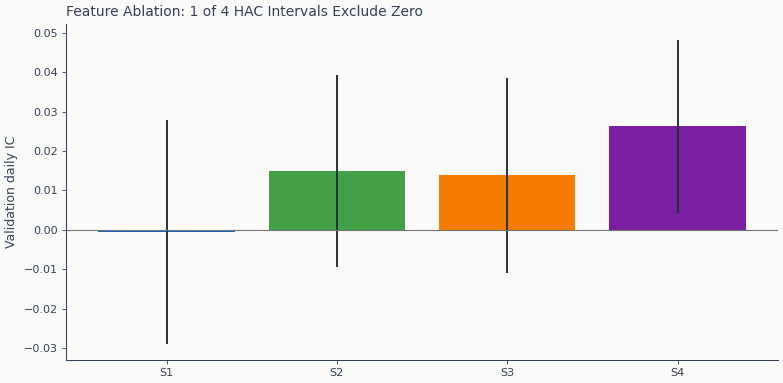

In [16]:
ablation_labels = [label.split(":", 1)[0] for label in ablation_results]
ablation_means = np.array([result["mean_ic"] for result in ablation_results.values()])
ablation_los = np.array([result["ci_lo"] for result in ablation_results.values()])
ablation_his = np.array([result["ci_hi"] for result in ablation_results.values()])
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ablation_labels, ablation_means, color=["#1565C0", "#43A047", "#F57C00", "#7B1FA2"])
ax.errorbar(
    ablation_labels,
    ablation_means,
    yerr=[ablation_means - ablation_los, ablation_his - ablation_means],
    fmt="none",
    color="#263238",
    capsize=4,
)
ax.axhline(0, color="#757575", linewidth=0.8)
ax.set_ylabel("Validation daily IC")
n_resolved_ablation = int(((ablation_los > 0) | (ablation_his < 0)).sum())
ax.set_title(
    f"Feature Ablation: {n_resolved_ablation} of {len(ablation_means)} HAC Intervals Exclude Zero"
)
fig.tight_layout()
fig.show()

## 4. Experiment 2 - IV Lag Decay

If the high IC comes from genuine VRP persistence (mean reversion of IV over
weeks), then lagging `iv_atm_z_252` should retain most of its predictive
power. If instead the IC reflects a near-tautological same-period overlap,
it should decay sharply with even small lags.

We compute cross-sectional Spearman IC of `iv_atm_z_252` shifted by $k$
sessions within each symbol, against `fwd_ret_dh_10d`, averaged across
validation dates.

Use one shared daily-IC calculation for the lag and return-decomposition
experiments.

In [17]:
def mean_daily_ic(frame: pl.DataFrame, feature: str, target: str) -> float:
    panel = frame.select(
        pl.col(date_col).alias("timestamp"),
        "symbol",
        pl.col(feature).alias("y_score"),
        pl.col(target).alias("y_true"),
    ).drop_nulls()
    daily = cross_sectional_ic_series(
        panel,
        panel,
        pred_col="y_score",
        ret_col="y_true",
        date_col="timestamp",
        entity_col="symbol",
        min_obs=20,
    ).drop_nulls("ic")
    return float(daily["ic"].mean())

Shift only after sorting the validation panel within symbol.

In [18]:
lags = [0, 5, 10, 15, 20, 42, 63]
ic_panel = validation_dataset.select([date_col, "symbol", "iv_atm_z_252", label_col]).sort(
    "symbol", date_col
)
lag_ic_results = {}
lag_autocorr = {}
for lag in lags:
    lagged = ic_panel.with_columns(
        pl.col("iv_atm_z_252").shift(lag).over("symbol").alias("iv_lagged")
    )
    lag_ic_results[lag] = mean_daily_ic(lagged, "iv_lagged", label_col)
    if lag > 0:
        lag_autocorr[lag] = lagged.drop_nulls().select(pl.corr("iv_atm_z_252", "iv_lagged")).item()
    else:
        lag_autocorr[lag] = 1.0

In [19]:
print("IV Lag Decay: iv_atm_z_252 → fwd_ret_dh_10d")
print("=" * 60)
print(f"{'Lag (sessions)':>14s}  {'IC':>8s}  {'% of lag=0':>12s}  {'IV autocorr':>12s}")
print("-" * 60)
ic_0 = lag_ic_results[0]
for lag in lags:
    ic = lag_ic_results[lag]
    pct = 100 * ic / ic_0 if ic_0 != 0 else np.nan
    ac = lag_autocorr[lag]
    print(f"{lag:14d}  {ic:+8.4f}  {pct:11.1f}%  {ac:12.3f}")

retention_10 = lag_ic_results[10] / ic_0 if ic_0 != 0 else np.nan
print(f"\nIC retention at lag=10: {retention_10:.1%}")
# The retention ratio is only meaningful when the lag-0 baseline is non-trivial;
# a near-zero baseline inflates the ratio into the hundreds of percent.
if abs(ic_0) < 0.01:
    print(f"→ lag-0 IC is negligible ({ic_0:+.4f}); retention ratio not meaningful")
elif retention_10 > 0.80:
    print("→ >80% retained: genuine VRP persistence (weeks-scale mean reversion)")
elif retention_10 > 0.50:
    print("→ 50-80% retained: mixed persistence and overlap")
else:
    print("→ <50% retained: rapid decay suggests same-period information overlap")

IV Lag Decay: iv_atm_z_252 → fwd_ret_dh_10d
Lag (sessions)        IC    % of lag=0   IV autocorr
------------------------------------------------------------
             0   +0.0035        100.0%         1.000
             5   +0.0158        452.6%         0.669
            10   +0.0293        840.8%         0.465
            15   +0.0160        458.9%         0.320
            20   -0.0094       -269.9%         0.217
            42   -0.0103       -296.2%         0.021
            63   +0.0178        511.7%        -0.025

IC retention at lag=10: 840.8%
→ lag-0 IC is negligible (+0.0035); retention ratio not meaningful


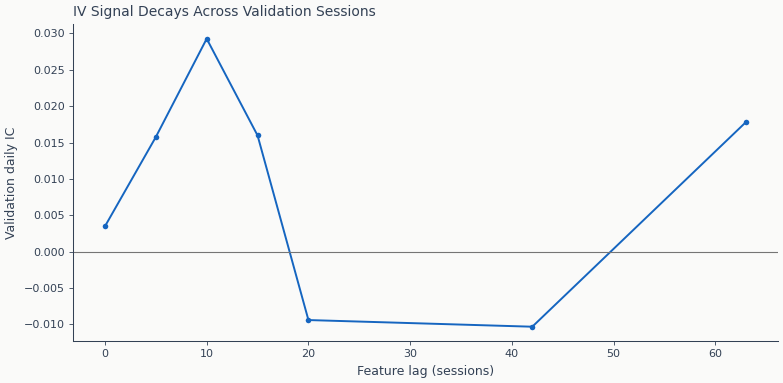

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lags, [lag_ic_results[lag] for lag in lags], marker="o", color="#1565C0")
ax.axhline(0, color="#757575", linewidth=0.8)
ax.set_xlabel("Feature lag (sessions)")
ax.set_ylabel("Validation daily IC")
ax.set_title("IV Signal Decays Across Validation Sessions")
fig.tight_layout()
fig.show()

## 5. Experiment 3 - Return Decomposition

Delta-hedged straddle returns decompose as:

$$r_{\text{dh}} = r_{\text{unhedged}} - r_{\text{hedge}}$$

where the hedge contribution captures the equity beta removed by delta
hedging. We measure IC of top features against each component to understand
whether the model predicts the option-specific component (VRP) or just
equity direction.

In [21]:
# Join the unhedged label to the sealed validation panel.
decomp = validation_dataset.join(
    unhedged_label.rename({"fwd_ret_10d": "fwd_ret_unhedged"}),
    on=["timestamp", "symbol"],
    how="inner",
).with_columns(hedge_contribution=(pl.col("fwd_ret_unhedged") - pl.col(label_col)))

print(f"Decomposition panel: {len(decomp):,} rows")

# Panel-wide correlation between unhedged and delta-hedged
corr_uh_dh = decomp.select(pl.corr("fwd_ret_unhedged", label_col)).item()
print(f"corr(unhedged, delta-hedged): {corr_uh_dh:.3f}")

Decomposition panel: 132,583 rows
corr(unhedged, delta-hedged): 0.620


Compare financial features only. Fold-specific temporal estimates remain
inside the fold-aware ablation experiment rather than using a placeholder
fold in this descriptive panel.

In [22]:
top_features = [
    "iv_atm_z_252",
    "vrp_21d",
    "iv_atm",
    "instr_pct_of_S",
    "ret_1d",
    "rv_21d",
    "volume_zscore",
]
decomp_targets = [
    (label_col, "delta-hedged"),
    ("fwd_ret_unhedged", "unhedged"),
    ("hedge_contribution", "hedge_contrib"),
]
decomp_results = []
for feature in top_features:
    for target, target_name in decomp_targets:
        decomp_results.append(
            {
                "feature": feature,
                "target": target_name,
                "ic": mean_daily_ic(decomp, feature, target),
            }
        )

decomp_df = (
    pd.DataFrame(decomp_results)
    .pivot(index="feature", columns="target", values="ic")
    .reindex(top_features)[["delta-hedged", "unhedged", "hedge_contrib"]]
)

Print the exact daily-IC matrix before rendering it as a heatmap.

In [23]:
print("\nReturn Decomposition IC")
print("=" * 70)
print(f"{'Feature':>20s}  {'Delta-Hedged':>13s}  {'Unhedged':>10s}  {'Hedge Contrib':>14s}")
print("-" * 70)
for feat in top_features:
    row = decomp_df.loc[feat]
    print(
        f"{feat:>20s}  {row['delta-hedged']:+13.4f}  {row['unhedged']:+10.4f}  {row['hedge_contrib']:+14.4f}"
    )


Return Decomposition IC
             Feature   Delta-Hedged    Unhedged   Hedge Contrib
----------------------------------------------------------------------
        iv_atm_z_252        +0.0035     +0.0114         -0.0008
             vrp_21d        +0.0504     +0.0178         -0.0307
              iv_atm        +0.0094     +0.0177         +0.0053
      instr_pct_of_S        +0.0040     +0.0081         +0.0006
              ret_1d        +0.0056     +0.0081         +0.0093
              rv_21d        -0.0198     +0.0058         +0.0254
       volume_zscore        +0.0078     +0.0239         +0.0208


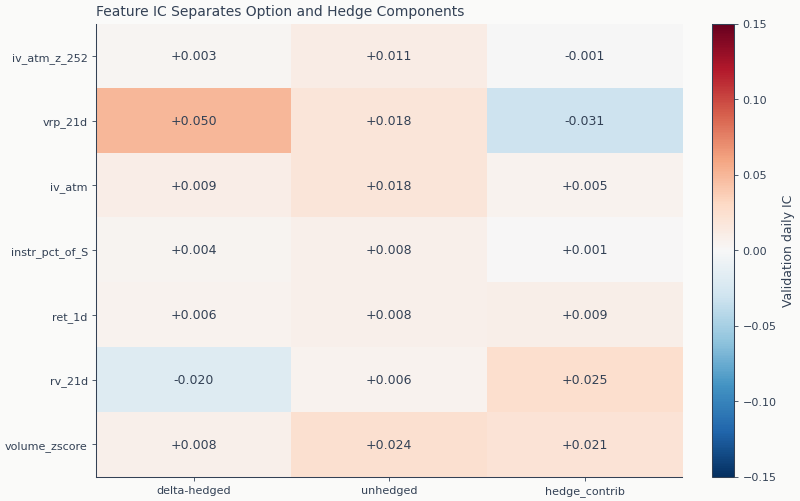

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(decomp_df.to_numpy(), cmap="RdBu_r", vmin=-0.15, vmax=0.15, aspect="auto")
ax.set_xticks(range(len(decomp_df.columns)), decomp_df.columns)
ax.set_yticks(range(len(decomp_df.index)), decomp_df.index)
for row_idx in range(len(decomp_df.index)):
    for col_idx in range(len(decomp_df.columns)):
        ax.text(
            col_idx, row_idx, f"{decomp_df.iloc[row_idx, col_idx]:+.3f}", ha="center", va="center"
        )
ax.set_title("Feature IC Separates Option and Hedge Components")
fig.colorbar(image, ax=ax, label="Validation daily IC")
fig.show()

### Decomposition Interpretation

If IV features have high IC against delta-hedged returns but near-zero IC
against the hedge contribution, the model captures the VRP component
(option-specific) and not just equity beta.

In [25]:
iv_dh_ic = decomp_df.loc["iv_atm_z_252", "delta-hedged"]
iv_uh_ic = decomp_df.loc["iv_atm_z_252", "unhedged"]
iv_hedge_ic = decomp_df.loc["iv_atm_z_252", "hedge_contrib"]

print("iv_atm_z_252 IC breakdown:")
print(f"  Delta-hedged:   {iv_dh_ic:+.4f}")
print(f"  Unhedged:       {iv_uh_ic:+.4f}")
print(f"  Hedge contrib:  {iv_hedge_ic:+.4f}")

if abs(iv_hedge_ic) < 0.03:
    print("→ Near-zero hedge IC: model predicts VRP, not equity direction")
else:
    print(f"→ Non-trivial hedge IC ({iv_hedge_ic:+.3f}): some equity direction signal")

iv_atm_z_252 IC breakdown:
  Delta-hedged:   +0.0035
  Unhedged:       +0.0114
  Hedge contrib:  -0.0008
→ Near-zero hedge IC: model predicts VRP, not equity direction


## 6. Experiment 4 - Effective Degrees of Freedom

PCA on the latest fold's training-only standardized design measures the
feature panel's effective dimensionality without fitting on validation or
holdout rows.

In [26]:
# Reuse canonical fold-aware preprocessing, including temporal fold identity.
pca_folds = prepare_cv_folds(
    dataset_pd,
    splits[:1],
    feature_names,
    label_col,
    date_col,
    entity_col,
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
)
X_clean = pca_folds[0]["X_train"]
pca = PCA()
pca.fit(X_clean)

cumvar = np.cumsum(pca.explained_variance_ratio_)
n_90 = int(np.searchsorted(cumvar, 0.90)) + 1
n_95 = int(np.searchsorted(cumvar, 0.95)) + 1
n_99 = int(np.searchsorted(cumvar, 0.99)) + 1

print("PCA: Effective Degrees of Freedom")
print("=" * 50)
print(f"Components for 90% variance: {n_90} / {len(feature_names)}")
print(f"Components for 95% variance: {n_95} / {len(feature_names)}")
print(f"Components for 99% variance: {n_99} / {len(feature_names)}")
print(f"\nTop 5 eigenvalues: {pca.explained_variance_ratio_[:5]}")
print(f"PC1 explains: {pca.explained_variance_ratio_[0]:.1%}")

PCA: Effective Degrees of Freedom
Components for 90% variance: 18 / 51
Components for 95% variance: 23 / 51
Components for 99% variance: 31 / 51

Top 5 eigenvalues: [0.21723357 0.20422434 0.07067203 0.05579145 0.04739827]
PC1 explains: 21.7%


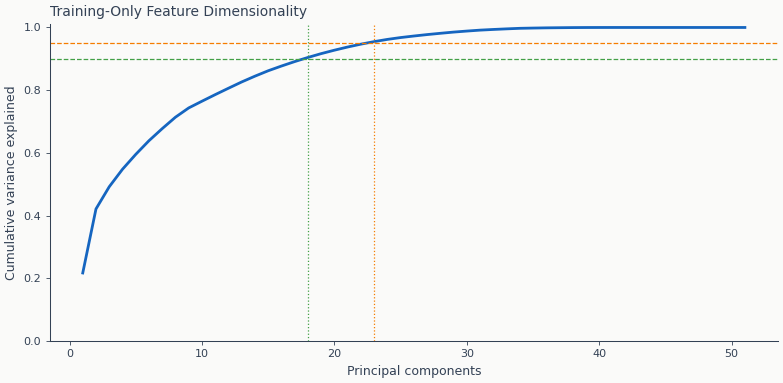

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
components = np.arange(1, len(cumvar) + 1)
ax.plot(components, cumvar, color="#1565C0", linewidth=2)
for threshold, count, color in [(0.90, n_90, "#43A047"), (0.95, n_95, "#F57C00")]:
    ax.axhline(threshold, color=color, linestyle="--", linewidth=0.9)
    ax.axvline(count, color=color, linestyle=":", linewidth=0.9)
ax.set_xlabel("Principal components")
ax.set_ylabel("Cumulative variance explained")
ax.set_ylim(0, 1.01)
ax.set_title("Training-Only Feature Dimensionality")
fig.tight_layout()
fig.show()

In [28]:
# Top-loading features on PC1
pc1_loadings = pd.Series(pca.components_[0], index=feature_names).abs().sort_values(ascending=False)
print("\nTop 10 features loading on PC1:")
for feat, loading in pc1_loadings.head(10).items():
    group = "A" if feat in group_a_set else "B"
    print(f"  {feat:25s}  |loading|={loading:.3f}  (Group {group})")

n_groupA_in_top10 = sum(1 for f in pc1_loadings.head(10).index if f in group_a_set)
print(f"\nGroup A features in PC1 top-10: {n_groupA_in_top10}/10")


Top 10 features loading on PC1:
  vrp_21d                    |loading|=0.267  (Group A)
  sv_vrp                     |loading|=0.262  (Group A)
  iv_rv_ratio                |loading|=0.248  (Group A)
  vrp_10d                    |loading|=0.244  (Group A)
  rv_21d                     |loading|=0.234  (Group B)
  iv_rv_ratio_pctl           |loading|=0.224  (Group A)
  vrp_21d_pctl               |loading|=0.224  (Group A)
  rv_10d                     |loading|=0.221  (Group B)
  sv_vol                     |loading|=0.217  (Group B)
  vrp_42d                    |loading|=0.216  (Group A)

Group A features in PC1 top-10: 7/10


## 7. Findings Summary

In [29]:
print("=" * 70)
print("IC DIAGNOSTIC SUMMARY: sp500_options")
print("=" * 70)

print("\n1. FEATURE ABLATION (Ridge α=10)")
print(f"   Single feature (iv_atm_z_252):     IC = {ic_s1:+.4f}")
print(f"   All IV-dependent (Group A, n={len(GROUP_A)}):  IC = {ic_s2:+.4f}")
print(f"   All IV-independent (Group B, n={len(GROUP_B)}): IC = {ic_s3:+.4f}")
print(f"   All {len(feature_names)} features:                   IC = {ic_s4:+.4f}")
print(f"   All-feature margin over S1: {ic_s4 - ic_s1:+.4f}")

print("\n2. IV LAG DECAY")
print(f"   IC at lag=0:  {lag_ic_results[0]:+.4f}")
print(f"   IC at lag=10: {lag_ic_results[10]:+.4f} ({retention_10:.0%} retained)")
print(f"   IC at lag=20: {lag_ic_results[20]:+.4f} ({lag_ic_results[20] / ic_0:.0%} retained)")
print(f"   IC at lag=63: {lag_ic_results[63]:+.4f} ({lag_ic_results[63] / ic_0:.0%} retained)")

print("\n3. RETURN DECOMPOSITION")
print(f"   corr(unhedged, delta-hedged): {corr_uh_dh:.3f}")
print(f"   iv_atm_z_252 IC vs delta-hedged:   {iv_dh_ic:+.4f}")
print(f"   iv_atm_z_252 IC vs unhedged:        {iv_uh_ic:+.4f}")
print(f"   iv_atm_z_252 IC vs hedge component: {iv_hedge_ic:+.4f}")

print("\n4. EFFECTIVE DIMENSIONALITY")
print(f"   Components for 90% variance: {n_90}")
print(f"   Components for 95% variance: {n_95}")
print(
    f"   PC1 explains {pca.explained_variance_ratio_[0]:.1%} "
    f"(top-10 loadings: {n_groupA_in_top10}/10 are Group A)"
)

IC DIAGNOSTIC SUMMARY: sp500_options

1. FEATURE ABLATION (Ridge α=10)
   Single feature (iv_atm_z_252):     IC = -0.0007
   All IV-dependent (Group A, n=33):  IC = +0.0150
   All IV-independent (Group B, n=18): IC = +0.0138
   All 51 features:                   IC = +0.0263
   All-feature margin over S1: +0.0270

2. IV LAG DECAY
   IC at lag=0:  +0.0035
   IC at lag=10: +0.0293 (841% retained)
   IC at lag=20: -0.0094 (-270% retained)
   IC at lag=63: +0.0178 (512% retained)

3. RETURN DECOMPOSITION
   corr(unhedged, delta-hedged): 0.620
   iv_atm_z_252 IC vs delta-hedged:   +0.0035
   iv_atm_z_252 IC vs unhedged:        +0.0114
   iv_atm_z_252 IC vs hedge component: -0.0008

4. EFFECTIVE DIMENSIONALITY
   Components for 90% variance: 18
   Components for 95% variance: 23
   PC1 explains 21.7% (top-10 loadings: 7/10 are Group A)


Synthesize the exploratory evidence without promoting the diagnostic label
into model selection or the case-level economic conclusion.

In [30]:
print("\n" + "=" * 70)
print("SYNTHESIS")
print("=" * 70)
full_result = ablation_results[all_features_label]
full_resolved = full_result["ci_lo"] > 0 or full_result["ci_hi"] < 0
print(
    f"The all-feature Ridge IC is {ic_s4:+.4f} with HAC interval "
    f"[{full_result['ci_lo']:+.4f}, {full_result['ci_hi']:+.4f}]."
)
print(f"The interval {'excludes' if full_resolved else 'includes'} zero.")
print(
    f"IV lag-10 retention is {retention_10:.1%}; the IV feature's hedge-component "
    f"IC is {iv_hedge_ic:+.4f}."
)
print(
    "These are validation-only diagnostics for fwd_ret_dh_10d. They do not enter "
    "the ret_to_expiry selection cohort, registry, holdout, or case-level decision."
)


SYNTHESIS
The all-feature Ridge IC is +0.0263 with HAC interval [+0.0042, +0.0484].
The interval excludes zero.
IV lag-10 retention is 840.8%; the IV feature's hedge-component IC is -0.0008.
These are validation-only diagnostics for fwd_ret_dh_10d. They do not enter the ret_to_expiry selection cohort, registry, holdout, or case-level decision.


## Key Takeaways

1. The legacy 10-session label is useful for mechanism checks but remains
   outside the production selection and backtest funnel.
2. Ablation uncertainty is computed from one pooled daily validation IC
   series with a 10-session HAC horizon, not from fold-level averages.
3. Lag and return decomposition use validation dates only; PCA fits the
   latest fold's training rows only. The 2021 holdout remains untouched.
4. These diagnostics can explain a signal mechanism, but they cannot reverse
   the case-level conclusion from the accepted `ret_to_expiry` carrier.